# 이미지를 텍스트로 검색/생성 RAG
- 해당 문서는 Colab에서 실행하였음.

In [6]:
%pip install -Uqqq langchain langchain-openai langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive  # Colab에서 구글드라이브 사용 모듈
drive.mount('/content/drive')   # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag'

Mounted at /content/drive


In [5]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')

## 이미지 캡셔닝 & 벡터db 저장

In [7]:
# 이미지 파일을 Base64 문자열로 변환하는 함수
import base64            # 바이너리 데이터 <-> Base64 인코딩/디코딩
from PIL import Image

def image_to_base64(image_path):
    with open(image_path, 'rb') as f:  # 파일을 바이너리 읽기 모드로 열기
        encoded = base64.b64encode(f.read()).decode('utf-8')  # Base64 인코딩 후 문자열로 변환
    return encoded

image_to_base64(f'{BASE_PATH}/figures/figure-1.jpg')

'...'

In [9]:
from openai import OpenAI

client = OpenAI()

def summarize_image(image_path):
    encoded = image_to_base64(image_path)

    response = client.chat.completions.create(
        model = 'gpt-5.6-luna',
        messages = [
            {
                'role': 'system',
                'content': '''
아래 아미지를 안전교육 및 화재대피 관점에서
주제문구와 각 장면에 대한 정보를 빠짐없이 한국어로 설명해주세요.
'''  # 모델에게 부여하는 지침(역할 및 설명 방식 정의)
            },
            {
                'role': 'user',
                'content': [{
                    'type': 'image_url',  # 이미지 입력 타입 지정
                    'image_url': {
                        'url': f'data:image/jpeg;base64,{encoded}'  # Base64 인코딩된 이미지 전달
                    }
                }]
            }
        ]
    )
    return response.choices[0].message.content  # 생성한 답변 텍스트

print(summarize_image(f'{BASE_PATH}/figures/figure-1.jpg'))

## 주제 문구

**“완강기 사용 방법(FIRE ESCAPE DEVICE)”**을 안내하는 화재 대피 안전교육 이미지입니다.  
화재 등으로 계단이나 승강기를 이용하기 어려울 때, 완강기를 이용해 창밖으로 안전하게 내려가는 기본 순서를 보여줍니다.

> 실제 대피 시에는 **119에 신고하고, 연기와 불길이 없는 안전한 경로를 우선 이용**해야 합니다. 완강기는 설치된 건물과 제품의 사용법에 따라 사용하며, 평소 위치와 사용 방법을 미리 확인해야 합니다.

---

## 장면 1. 후크를 고리에 안전하게 건다

- 그림에는 완강기의 **후크**를 건물 벽이나 창가에 설치된 **고정용 고리(아이볼트)**에 거는 모습이 나옵니다.
- 안내 문구:  
  **“후크를 고리에 안전하게 건다.”**  
  **“Hang the Hook to the eyebolt safely.”**
- 후크가 고리에 완전히 걸렸는지, 빠지거나 흔들리지 않는지 확인해야 합니다.
- 고정 고리가 아닌 창틀, 난간, 배관 등 임의의 장소에 걸어서는 안 됩니다.
- 후크가 제대로 체결되지 않으면 하강 중 장치가 빠져 추락할 수 있으므로, 반드시 연결 상태를 점검해야 합니다.

---

## 장면 2. 릴을 창밖으로 던진다

- 그림에는 창가에서 **릴(reel)** 또는 완강기 본체를 창밖으로 내보내는 모습이 표시되어 있습니다.
- 안내 문구:  
  **“릴(줄)을 창밖으로 던진다.”**  
  **“Throw the reel out of the window.”**
- 완강기의 줄과 릴이 창밖으로 완전히 빠져나가도록 하여, 하강할 공간을 확보합니다.
- 줄이 실내 가구, 창틀, 난간 등에 걸리거나 꼬이지 않았는지 확인해야 합니다.
- 아래에 사람이 있거나 장애물이 있는 경우에는 “위에서 내려갑니다”라고 알리고, 안전이 확보될 때까지 기다려야 합니다.
- 창문을 열 때 유리 파편이나 불꽃에 다치지 않도록 주의하며, 연기가 심한 곳에서는 몸을 낮춰 행동합니다.

---

## 장면 3. 벨트를

In [13]:
# vector db 구축
from langchain_chroma.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from tqdm.auto import tqdm
import os

persistent_dir = f'{BASE_PATH}/chroma'  # 벡터DB 저장 경로

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_db = Chroma(
    collection_name = 'multimodal_rag',  # 컬렉션(테이블) 이름
    embedding_function = embeddings,     # 사용할 임베딩 함수
    persist_directory = persistent_dir   # 저장할 경로
)

In [14]:
# 이미지 목록 생성 및 캡션 기반 VectorDB 저장
figure_dir = os.path.join(BASE_PATH, 'figures')  # figures 폴더

image_files = [
    os.path.join(figure_dir, filename)      # 완성된 전체 경로 반환
    for filename in os.listdir(figure_dir)  # 폴더 내 파일 목록 순회
    if filename.lower().endswith(('.png', '.jpg', '.jpeg'))  # 확장자가 이미지 파일이면
]

for img_path in tqdm(image_files):
    b64_str = image_to_base64(img_path)
    caption = summarize_image(img_path)

    vector_db.add_texts(
        texts = [caption],  # 이미지 요약
        metadatas = [
            {
                'base64_image': b64_str,    # 원본 이미지
                'image_path': img_path      # 파일 경로
            }
        ]
    )

  0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
# vector DB 데이터 조회
docs = vector_db._collection.get()  # Chroma DB 컬렉션에 저장된 전체 문서 / 메타데이터 조회

for i, (page_content, metadata) in enumerate(zip(docs['documents'], docs['metadatas'])):
    print(f"{i+1}번 :")
    print(f"{page_content = }")  # page_content = {page_content}
    print(f"{metadata = }")
    print()

1번 :
page_content = '## 이미지 주제\n\n**완강기 사용 방법(FIRE ESCAPE DEVICE)**\n\n화재나 비상 상황에서 건물의 창문을 통해 **완강기**를 이용하여 아래층으로 대피하는 방법을 안내한 안전교육 자료입니다. 그림은 완강기의 고정, 릴 투척, 안전벨트 착용, 벽을 마주 보며 하강하는 순서로 구성되어 있습니다.\n\n---\n\n## 장면 1. 훅을 고리에 안전하게 건다\n\n- **그림 내용:** 완강기의 훅을 건물 벽이나 창가에 설치된 **고정용 아이볼트(고리)**에 걸고 있습니다.\n- **안내 문구:**  \n  - 한국어: **“훅을 고리에 안전하게 건다.”**  \n  - 영어: **“Hang the Hook to the eyebolt safely.”**\n- **안전교육 설명:**\n  1. 훅이 아이볼트에 완전히 걸렸는지 확인합니다.\n  2. 훅이 빠지거나 흔들리지 않도록 단단히 고정되었는지 점검합니다.\n  3. 고정 지점이 아닌 창틀, 난간, 배관 등에 임의로 걸어서는 안 됩니다.\n  4. 고정 장치나 완강기에 손상이 있으면 사용하지 말아야 합니다.\n\n---\n\n## 장면 2. 릴과 줄을 창밖으로 던진다\n\n- **그림 내용:** 완강기의 릴 또는 줄 부분을 창밖으로 내보내고 있습니다.\n- **안내 문구:**  \n  - 한국어: **“리일(줄)을 창밖으로 던진다.”**  \n  - 영어: **“Throw the reel out of the window.”**\n- **안전교육 설명:**\n  1. 훅을 고정한 뒤 릴과 연결 줄을 창밖으로 충분히 내보냅니다.\n  2. 줄이 창틀이나 외벽의 돌출물에 걸리지 않았는지 확인합니다.\n  3. 줄이 꼬이거나 매듭이 생기지 않도록 정리합니다.\n  4. 아래쪽에 사람이 있거나 장애물이 있는 경우 주의하여 대피해야 합니다.\n  5. 창문을 열 때 유리 파편이나 뜨거운 연기에 주의하고, 무리하게 창문을 열어 화재가 확대되지 않도록 합니다.\n\n---\

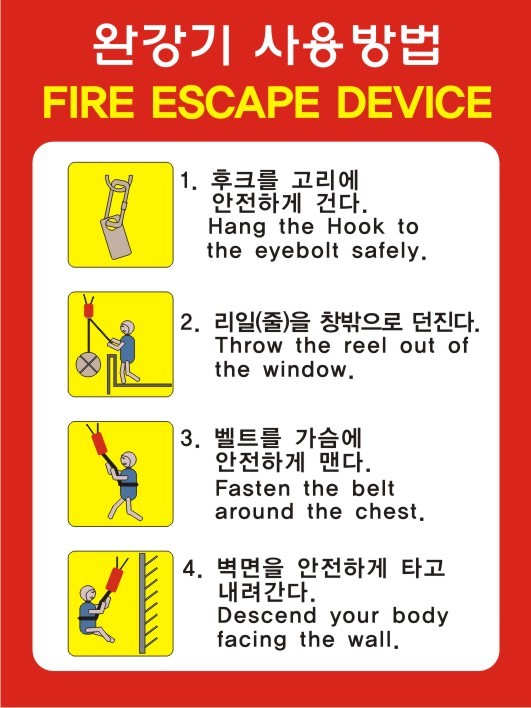

In [16]:
# Base64 이미지를 화면에 출력
from io import BytesIO
from PIL import Image

def show_base64_image(b64_str):
    img = Image.open(BytesIO(base64.b64decode(b64_str)))  # Base64 디코딩 후 이미지 객체형식으로 생성
    display(img)

show_base64_image(docs['metadatas'][0]['base64_image'])

1 : ## 이미지 주제

**완강기 사용 방법(FIRE ESCAPE DEVICE)**

화재나 비상 상황에서 건물의 창문을 통해 **완강기**를 이용하여 아래층으로 대피하는 방법을 안내한 안전교육 자료입니다. 그림은 완강기의 고정, 릴 투척, 안전벨트 착용, 벽을 마주 보며 하강하는 순서로 구성되어 있습니다.

---

## 장면 1. 훅을 고리에 안전하게 건다

- **그림 내용:** 완강기의 훅을 건물 벽이나 창가에 설치된 **고정용 아이볼트(고리)**에 걸고 있습니다.
- **안내 문구:**  
  - 한국어: **“훅을 고리에 안전하게 건다.”**  
  - 영어: **“Hang the Hook to the eyebolt safely.”**
- **안전교육 설명:**
  1. 훅이 아이볼트에 완전히 걸렸는지 확인합니다.
  2. 훅이 빠지거나 흔들리지 않도록 단단히 고정되었는지 점검합니다.
  3. 고정 지점이 아닌 창틀, 난간, 배관 등에 임의로 걸어서는 안 됩니다.
  4. 고정 장치나 완강기에 손상이 있으면 사용하지 말아야 합니다.

---

## 장면 2. 릴과 줄을 창밖으로 던진다

- **그림 내용:** 완강기의 릴 또는 줄 부분을 창밖으로 내보내고 있습니다.
- **안내 문구:**  
  - 한국어: **“리일(줄)을 창밖으로 던진다.”**  
  - 영어: **“Throw the reel out of the window.”**
- **안전교육 설명:**
  1. 훅을 고정한 뒤 릴과 연결 줄을 창밖으로 충분히 내보냅니다.
  2. 줄이 창틀이나 외벽의 돌출물에 걸리지 않았는지 확인합니다.
  3. 줄이 꼬이거나 매듭이 생기지 않도록 정리합니다.
  4. 아래쪽에 사람이 있거나 장애물이 있는 경우 주의하여 대피해야 합니다.
  5. 창문을 열 때 유리 파편이나 뜨거운 연기에 주의하고, 무리하게 창문을 열어 화재가 확대되지 않도록 합니다.

---

## 장면 3. 벨트를 가슴에 안전하게 맨다

- **그림 내용:** 사용자가 완강기의 안전

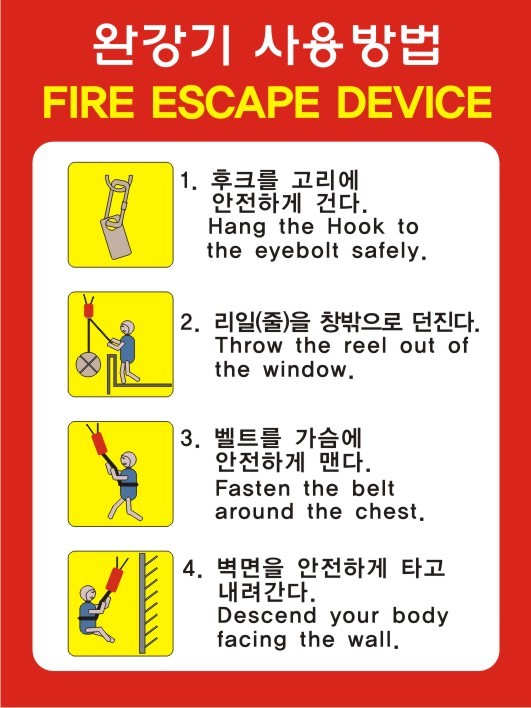

In [17]:
query = '완강기는 어떻게 써야하나?'
docs = vector_db.similarity_search(query, k=2)  # 질문과 유사한 상위 2개 문서 검색

for i, doc in enumerate(docs):
    print(f"{i + 1} : {doc.page_content}")  # 캡션 내용
    show_base64_image(doc.metadata['base64_image'])  # 이미지 출력

## Multimodal RAG 구현
- agentic rag 구현 (middleware기반 검색된 문서 제공)
- text + image 응답

In [18]:
from langchain.chat_models import init_chat_model  # LLM 초기화
from langchain.agents import create_agent          # 에이전트 생성
from langchain.agents.middleware import AgentMiddleware, AgentState  # 에이전트 미들웨어 / 상태 타입
from langchain_core.documents import Document      # 검색 결과 문서 타입
from typing import Any  # 타입 힌트용

# 에이전트가 유지할 상태 스키마
class State(AgentState):
    context: list[Document]

# 모델 호출 전에 문서 검색 및 프롬프트 재작성 미들웨어
class RetrieveDocumentsMiddleware(AgentMiddleware[State]):
    state_schema = State  # 이 미들웨어의 상태 스키마

    # 상태를 입력받아 출력이 {"messages": ...} 또는 None 반환
    def before_model(self, state: AgentState) -> dict[str, Any] | None:
        last_message = state['messages'][-1]  # 사용자 메시지
        retrieved_docs = vector_db.similarity_search(last_message.text, k=2)  # 질문과 유사한 문서 2개

        docs_content = '\n\n'.join(doc.page_content for doc in retrieved_docs)  # 하나의 문자열로 합침

        prompt = f"""
제공된 '참조 문서'의 내용을 바탕으로 '사용자 질문'에 대해 상세히 답변하라.

제약 조건:
- 답변은 반드시 제공된 문서 내의 정보만을 근거로 작성한다.
- 문서에서 답을 찾을 수 없는 경우, "제공된 정보에서는 해당 내용을 확인할 수 없습니다"라고 답변한다.
- 논리적이고 가독성이 좋게 구조화하여 설명한다.

참조 문서:
{docs_content}

사용자 질문:
{last_message.text}
"""
        return {
            # 사용자 메시지를 프롬프트로 바꿔서 모델에 전달
            'messages': [last_message.model_copy(update={'content': prompt})],
            'context': retrieved_docs  # 검색된 문서 (상태 저장)
        }

# 화재 시 완강기 사용법

완강기는 계단이나 비상구 등 더 안전한 대피로를 이용하기 어려울 때, 건물 창문을 통해 아래층으로 대피하는 장치입니다. 사용 전 현장에 설치된 완강기의 사용 설명서와 안전표지를 확인하고, 제품별 허용 하중과 사용법을 따라야 합니다.

## 1. 먼저 대피 상황을 알리고 안전을 확인합니다

- “불이야”라고 알리고 **119에 신고**합니다.
- 창문 밖으로 탈출하기 전에 계단이나 비상구 등 더 안전한 대피로가 있는지 확인합니다.
- 엘리베이터는 사용하지 말고 계단을 이용합니다.
- 연기가 많으면 몸을 낮추고 젖은 천 등으로 코와 입을 가립니다.
- 가능한 경우 문을 닫아 연기와 불길의 확산을 늦춥니다.
- 불길, 짙은 연기, 강한 열기 또는 구조물 손상이 심하면 무리하게 완강기를 사용하지 말고 소방대원의 지시에 따릅니다.

## 2. 훅을 고정용 고리에 겁니다

1. 완강기의 훅을 건물 벽이나 창가에 설치된 **고정용 아이볼트(고리)**에 겁니다.
2. 훅이 아이볼트에 완전히 걸렸는지 확인합니다.
3. 훅이 빠지거나 흔들리지 않도록 단단히 고정되었는지 점검합니다.
4. 창틀, 난간, 배관 등 고정 지점이 아닌 곳에는 임의로 걸지 않습니다.
5. 고정 장치나 완강기에 손상이 있으면 사용하지 않습니다.

## 3. 릴과 줄을 창밖으로 내보냅니다

1. 훅을 고정한 뒤 완강기의 릴과 연결 줄을 창밖으로 충분히 내보냅니다.
2. 줄이 창틀이나 외벽의 돌출물에 걸리지 않았는지 확인합니다.
3. 줄이 꼬이거나 매듭이 생기지 않도록 정리합니다.
4. 아래쪽에 사람이나 장애물이 있는지 확인합니다.
5. 창문을 열 때는 유리 파편과 뜨거운 연기에 주의하고, 무리하게 창문을 열어 화재가 확대되지 않도록 합니다.

## 4. 안전벨트를 가슴에 착용합니다

1. 벨트를 가슴 부위에 정확히 걸고 단단히 조입니다.
2. 벨트가 목을 조르거나 한쪽 팔에만 걸리지 않도록 합니다.
3. 연결부와 버클이 제대로 잠겼는지 확인합니다.
4. 벨트를 헐겁게 착용하면 하

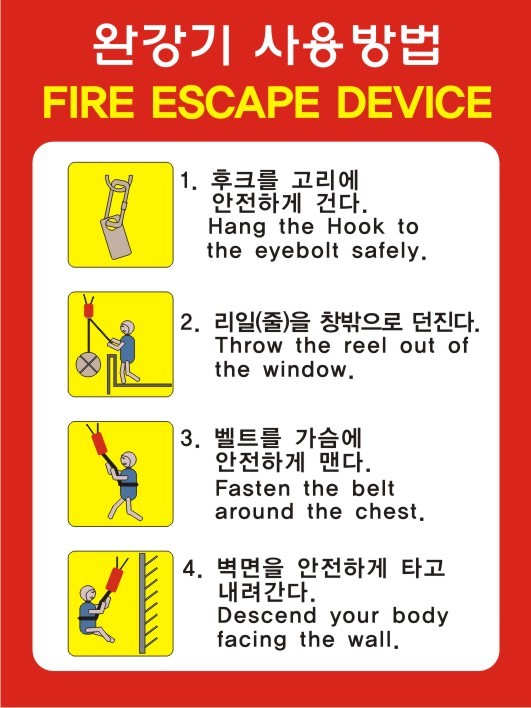

## 이미지 주제

**완강기 사용 방법(FIRE ESCAPE DEVICE)**

화재나 비상 상황에서 건물의 창문을 통해 **완강기**를 이용하여 아래층으로 대피하는 방법을 안내한 안전교육 자료입니다. 그림은 완강기의 고정, 릴 투척, 안전벨트 착용, 벽을 마주 보며 하강하는 순서로 구성되어 있습니다.

---

## 장면 1. 훅을 고리에 안전하게 건다

- **그림 내용:** 완강기의 훅을 건물 벽이나 창가에 설치된 **고정용 아이볼트(고리)**에 걸고 있습니다.
- **안내 문구:**  
  - 한국어: **“훅을 고리에 안전하게 건다.”**  
  - 영어: **“Hang the Hook to the eyebolt safely.”**
- **안전교육 설명:**
  1. 훅이 아이볼트에 완전히 걸렸는지 확인합니다.
  2. 훅이 빠지거나 흔들리지 않도록 단단히 고정되었는지 점검합니다.
  3. 고정 지점이 아닌 창틀, 난간, 배관 등에 임의로 걸어서는 안 됩니다.
  4. 고정 장치나 완강기에 손상이 있으면 사용하지 말아야 합니다.

---

## 장면 2. 릴과 줄을 창밖으로 던진다

- **그림 내용:** 완강기의 릴 또는 줄 부분을 창밖으로 내보내고 있습니다.
- **안내 문구:**  
  - 한국어: **“리일(줄)을 창밖으로 던진다.”**  
  - 영어: **“Throw the reel out of the window.”**
- **안전교육 설명:**
  1. 훅을 고정한 뒤 릴과 연결 줄을 창밖으로 충분히 내보냅니다.
  2. 줄이 창틀이나 외벽의 돌출물에 걸리지 않았는지 확인합니다.
  3. 줄이 꼬이거나 매듭이 생기지 않도록 정리합니다.
  4. 아래쪽에 사람이 있거나 장애물이 있는 경우 주의하여 대피해야 합니다.
  5. 창문을 열 때 유리 파편이나 뜨거운 연기에 주의하고, 무리하게 창문을 열어 화재가 확대되지 않도록 합니다.

---

## 장면 3. 벨트를 가슴에 안전하게 맨다

- **그림 내용:** 사용자가 완강기의 안전벨트를 

In [19]:
llm = init_chat_model('gpt-5.6-luna')
agent = create_agent(
    llm,
    tools = [],
    middleware = [RetrieveDocumentsMiddleware()]  # 모델 호출 전 검색/프롬프트 주입
)

response = agent.invoke({
    'messages': [
        ('human', '화재시 완강기 사용법을 알려줘.')
    ]
})

print(response['messages'][-1].content)  # 모델 응답

print('[검색된 내용]')
for doc in response['context']:
    show_base64_image(doc.metadata['base64_image'])  # 이미지 출력
    print(doc.page_content)  # 캡션 내용